In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import deque

import gymnasium as gym

import random

import matplotlib.pyplot as plt

In [2]:
from IPython import display
plt.ion()

In [3]:
neurons = 125

class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, neurons)
        self.layer2 = nn.Linear(neurons, neurons)
        self.layer3 = nn.Linear(neurons, n_actions)

    def forward(self, x):
        x = F.relu(input=self.layer1(x))
        x = F.relu(input=self.layer2(x))
        return self.layer3(x)

In [4]:
device = "cuda"

env = gym.make("CartPole-v1", render_mode="rgb_array")
state, info = env.reset()

n_observations = len(state)
n_actions = env.action_space.n

In [5]:
current_model = DQN(n_observations=n_observations, n_actions=n_actions).to(device)
target_model = DQN(n_observations=n_observations, n_actions=n_actions).to(device)
target_model.load_state_dict(state_dict=current_model.state_dict())

learning_rate = 0.001
optimizer = torch.optim.AdamW(current_model.parameters(), lr=learning_rate, amsgrad=True)

c:\Users\natha\Documents\Git\5th-year-polytech\Reinforcement Learning\env\Lib\site-packages\torch\nn\modules\module.py:1357: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  return t.to(


In [6]:
memory_length = 10000

memory = deque([], maxlen=memory_length)

In [7]:
episode_durations = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if not show_result:
        display.display(plt.gcf())
        display.clear_output(wait=True)
    else:
        display.display(plt.gcf())

Complete


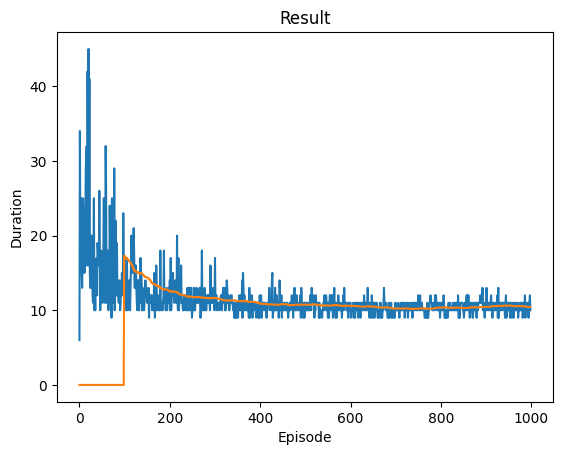

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
N_episodes = 1000
epsilon = 1
epsilon_decay = 0.995
batch_size = 32
target_updating_steps = 10
discount_factor = 0.99

for episode in range(N_episodes):
    state, info = env.reset()

    done = False

    t = 0

    while not done:
        random_sample = random.random()
        if random_sample <= epsilon:
            action = random.randint(0, n_actions - 1)

        else:
            with torch.no_grad():
                q_values = current_model(torch.tensor(state).to(device))
                action = torch.argmax(q_values).item()

        next_state, reward, done, truncated, _ = env.step(action)
        memory.append([state, action, reward, next_state])
        state = next_state

        if len(memory) >= batch_size:
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states = zip(*batch)
            states = torch.tensor(states).to(device)
            actions = torch.tensor(actions).to(device).unsqueeze(1).to(device)
            rewards = torch.tensor(rewards).to(device)
            next_states = torch.tensor(next_states).to(device)

            q_values = current_model(states).gather(1, actions).squeeze(1)

            with torch.no_grad():
                next_q_values = target_model(next_states).max(dim=1)[0]
            targets = rewards + discount_factor * next_q_values

            optimizer.zero_grad()
            loss = nn.MSELoss()(q_values, targets)
            loss.backward()
            optimizer.step()

            t += 1

            if done:
                episode_durations.append(t + 1)
                plot_durations()


    if episode % target_updating_steps == 0:
        target_model.load_state_dict(current_model.state_dict())


    epsilon = max(0.01, epsilon * epsilon_decay)

print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()